In [1]:
from pathlib import Path

def find_project_root(start=Path.cwd()):
    for p in [start, *start.parents]:
        if (p / 'README.md').exists() and (p / 'data').exists():
            return p
    raise FileNotFoundError('Project root not found. Make sure README.md and data/ exist.')

PROJECT_ROOT = find_project_root()
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR = PROJECT_ROOT / 'figures'

SLEEP_EDF_DIR = RAW_DIR / 'sleep_edf' / 'sleep-cassette'

print('PROJECT_ROOT =', PROJECT_ROOT)
print('SLEEP_EDF_DIR =', SLEEP_EDF_DIR)
print('Exists:', SLEEP_EDF_DIR.exists())


FileNotFoundError: Project root not found. Make sure README.md and data/ exist.

In [2]:
from pathlib import Path

PROJECT_ROOT = Path(r'C:\Users\vi\Sleep staging + fragmentation detection\sleep-staging-fragmentation')

RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR = PROJECT_ROOT / 'figures'
MODELS_DIR = PROJECT_ROOT / 'models'
NOTEBOOKS_DIR = PROJECT_ROOT / 'notebooks'

SLEEP_EDF_DIR = RAW_DIR / 'sleep_edf' / 'sleep-cassette'

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOKS_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT =', PROJECT_ROOT)
print('RAW_DIR =', RAW_DIR)
print('PROCESSED_DIR =', PROCESSED_DIR)
print('FIGURES_DIR =', FIGURES_DIR)
print('MODELS_DIR =', MODELS_DIR)
print('NOTEBOOKS_DIR =', NOTEBOOKS_DIR)
print('SLEEP_EDF_DIR =', SLEEP_EDF_DIR)
print('SLEEP_EDF_DIR exists =', SLEEP_EDF_DIR.exists())


PROJECT_ROOT = C:\Users\vi\Sleep staging + fragmentation detection\sleep-staging-fragmentation
RAW_DIR = C:\Users\vi\Sleep staging + fragmentation detection\sleep-staging-fragmentation\data\raw
PROCESSED_DIR = C:\Users\vi\Sleep staging + fragmentation detection\sleep-staging-fragmentation\data\processed
FIGURES_DIR = C:\Users\vi\Sleep staging + fragmentation detection\sleep-staging-fragmentation\figures
MODELS_DIR = C:\Users\vi\Sleep staging + fragmentation detection\sleep-staging-fragmentation\models
NOTEBOOKS_DIR = C:\Users\vi\Sleep staging + fragmentation detection\sleep-staging-fragmentation\notebooks
SLEEP_EDF_DIR = C:\Users\vi\Sleep staging + fragmentation detection\sleep-staging-fragmentation\data\raw\sleep_edf\sleep-cassette
SLEEP_EDF_DIR exists = True


In [3]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mnedef get_subject_prefix(filename):
    m = re.match(r'^(SC\d{4})', filename)
    return m.group(1) if m else None

psg_files = {}
hyp_files = {}

for f in edf_files:
    prefix = get_subject_prefix(f.name)
    if prefix is None:
        continue

    if '-PSG.edf' in f.name:
        psg_files[prefix] = f
    elif '-Hypnogram.edf' in f.name:
        hyp_files[prefix] = f

pairs = []
for prefix in sorted(set(psg_files) & set(hyp_files)):
    pairs.append({
        'subject_prefix': prefix,
        'psg_file': psg_files[prefix],
        'hypnogram_file': hyp_files[prefix]
    })

pairs_df = pd.DataFrame([
    {
        'subject_prefix': x['subject_prefix'],
        'psg_file': x['psg_file'].name,
        'hypnogram_file': x['hypnogram_file'].name
    }
    for x in pairs
])

pairs_df

In [4]:
edf_files = sorted(SLEEP_EDF_DIR.glob('*.edf'))

print(f'Found {len(edf_files)} EDF files:')
for f in edf_files:
    print(f.name)

Found 8 EDF files:
SC4001E0-PSG.edf
SC4001EC-Hypnogram.edf
SC4002E0-PSG.edf
SC4002EC-Hypnogram.edf
SC4011E0-PSG.edf
SC4011EH-Hypnogram.edf
SC4012E0-PSG.edf
SC4012EC-Hypnogram.edf


In [5]:
sample_pair = pairs[0]

psg_path = sample_pair['psg_file']
hyp_path = sample_pair['hypnogram_file']

print('PSG:', psg_path.name)
print('Hypnogram:', hyp_path.name)

NameError: name 'pairs' is not defined

In [6]:
print(SLEEP_EDF_DIR)
print(SLEEP_EDF_DIR.exists())

edf_files = sorted(SLEEP_EDF_DIR.glob('*.edf'))
print(f'Found {len(edf_files)} EDF files')
for f in edf_files:
    print(f.name)

C:\Users\vi\Sleep staging + fragmentation detection\sleep-staging-fragmentation\data\raw\sleep_edf\sleep-cassette
True
Found 8 EDF files
SC4001E0-PSG.edf
SC4001EC-Hypnogram.edf
SC4002E0-PSG.edf
SC4002EC-Hypnogram.edf
SC4011E0-PSG.edf
SC4011EH-Hypnogram.edf
SC4012E0-PSG.edf
SC4012EC-Hypnogram.edf


In [7]:
def get_subject_prefix(filename):
    m = re.match(r'^(SC\d{4})', filename)
    return m.group(1) if m else None

psg_files = {}
hyp_files = {}

for f in edf_files:
    prefix = get_subject_prefix(f.name)
    if prefix is None:
        continue

    if '-PSG.edf' in f.name:
        psg_files[prefix] = f
    elif '-Hypnogram.edf' in f.name:
        hyp_files[prefix] = f

pairs = []
for prefix in sorted(set(psg_files) & set(hyp_files)):
    pairs.append({
        'subject_prefix': prefix,
        'psg_file': psg_files[prefix],
        'hypnogram_file': hyp_files[prefix]
    })

pairs_df = pd.DataFrame([
    {
        'subject_prefix': x['subject_prefix'],
        'psg_file': x['psg_file'].name,
        'hypnogram_file': x['hypnogram_file'].name
    }
    for x in pairs
])

print(f'Found {len(pairs)} PSG/Hypnogram pairs')
pairs_df

Found 4 PSG/Hypnogram pairs


,subject_prefix,psg_file,hypnogram_file
0,SC4001,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf
1,SC4002,SC4002E0-PSG.edf,SC4002EC-Hypnogram.edf
2,SC4011,SC4011E0-PSG.edf,SC4011EH-Hypnogram.edf
3,SC4012,SC4012E0-PSG.edf,SC4012EC-Hypnogram.edf


In [8]:
sample_pair = pairs[0]

psg_path = sample_pair['psg_file']
hyp_path = sample_pair['hypnogram_file']

print('PSG:', psg_path.name)
print('Hypnogram:', hyp_path.name)

PSG: SC4001E0-PSG.edf
Hypnogram: SC4001EC-Hypnogram.edf


In [9]:
raw = mne.io.read_raw_edf(psg_path, preload=False, verbose=False)

print(raw)
print('\nChannel names:')
print(raw.ch_names)

<RawEDF | SC4001E0-PSG.edf, 7 x 7950000 (79500.0 s), ~10 KiB, data not loaded>

Channel names:
['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal', 'EMG submental', 'Temp rectal', 'Event marker']


C:\Users\vi\AppData\Local\Temp\ipykernel_40712\4035292733.py:1: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=False, verbose=False)
C:\Users\vi\AppData\Local\Temp\ipykernel_40712\4035292733.py:1: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=False, verbose=False)
C:\Users\vi\AppData\Local\Temp\ipykernel_40712\4035292733.py:1: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_path, preload=False, verbose=False)


In [10]:
annotations = mne.read_annotations(hyp_path)

print(annotations)
print('\nFirst 10 annotation descriptions:')
print(annotations.description[:10])

<Annotations | 154 segments: Sleep stage 1 (24), Sleep stage 2 (40), Sleep ...>

First 10 annotation descriptions:
['Sleep stage W' 'Sleep stage 1' 'Sleep stage 2' 'Sleep stage 3'
 'Sleep stage 2' 'Sleep stage 3' 'Sleep stage 4' 'Sleep stage 3'
 'Sleep stage 4' 'Sleep stage 3']


In [11]:
print(raw)
print(raw.ch_names)

<RawEDF | SC4001E0-PSG.edf, 7 x 7950000 (79500.0 s), ~10 KiB, data not loaded>
['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal', 'EMG submental', 'Temp rectal', 'Event marker']


In [12]:
print('Sampling frequency:', raw.info['sfreq'])
print('Recording duration (sec):', raw.times[-1])

channel_table = pd.DataFrame({
    'channel_name': raw.ch_names,
    'channel_type_guess': [mne.io.pick.channel_type(raw.info, i) for i in range(len(raw.ch_names))]
})

channel_table

Sampling frequency: 100.0
Recording duration (sec): 79499.99


AttributeError: module 'mne.io.pick' has no attribute 'channel_type'

In [13]:
print('Sampling frequency:', raw.info['sfreq'])
print('Recording duration (sec):', raw.times[-1])

channel_types = []
for i, ch in enumerate(raw.ch_names):
    try:
        ch_type = mne.channel_type(raw.info, i)
    except Exception:
        ch_type = 'unknown'
    channel_types.append(ch_type)

channel_table = pd.DataFrame({
    'channel_name': raw.ch_names,
    'channel_type_guess': channel_types
})

channel_table

Sampling frequency: 100.0
Recording duration (sec): 79499.99


,channel_name,channel_type_guess
0,EEG Fpz-Cz,eeg
1,EEG Pz-Oz,eeg
2,EOG horizontal,eeg
3,Resp oro-nasal,eeg
4,EMG submental,eeg
5,Temp rectal,eeg
6,Event marker,eeg


In [14]:
annot_df = pd.DataFrame({
    'onset_sec': annotations.onset,
    'duration_sec': annotations.duration,
    'description': annotations.description
})

annot_df.head(20)

,onset_sec,duration_sec,description
0,0.0,30630.0,Sleep stage W
1,30630.0,120.0,Sleep stage 1
2,30750.0,390.0,Sleep stage 2
3,31140.0,30.0,Sleep stage 3
4,31170.0,30.0,Sleep stage 2
5,31200.0,150.0,Sleep stage 3
6,31350.0,30.0,Sleep stage 4
7,31380.0,60.0,Sleep stage 3
8,31440.0,60.0,Sleep stage 4
9,31500.0,30.0,Sleep stage 3


In [15]:
annot_df['description'].value_counts(dropna=False)

description
Sleep stage 3    48
Sleep stage 2    40
Sleep stage 1    24
Sleep stage 4    23
Sleep stage W    12
Sleep stage R     6
Sleep stage ?     1
Name: count, dtype: int64

In [16]:
stage_map = {
    'Sleep stage W': 'W',
    'Sleep stage 1': 'N1',
    'Sleep stage 2': 'N2',
    'Sleep stage 3': 'N3',
    'Sleep stage 4': 'N3',
    'Sleep stage R': 'REM'
}

annot_df['stage_5class'] = annot_df['description'].map(stage_map)
annot_df[['description', 'stage_5class']].drop_duplicates().sort_values('description')

,description,stage_5class
1,Sleep stage 1,N1
2,Sleep stage 2,N2
3,Sleep stage 3,N3
6,Sleep stage 4,N3
153,Sleep stage ?,NaN
44,Sleep stage R,REM
0,Sleep stage W,W


In [17]:
stage_df = annot_df[annot_df['stage_5class'].notna()].copy()
stage_df.head(20)

,onset_sec,duration_sec,description,stage_5class
0,0.0,30630.0,Sleep stage W,W
1,30630.0,120.0,Sleep stage 1,N1
2,30750.0,390.0,Sleep stage 2,N2
3,31140.0,30.0,Sleep stage 3,N3
4,31170.0,30.0,Sleep stage 2,N2
5,31200.0,150.0,Sleep stage 3,N3
6,31350.0,30.0,Sleep stage 4,N3
7,31380.0,60.0,Sleep stage 3,N3
8,31440.0,60.0,Sleep stage 4,N3
9,31500.0,30.0,Sleep stage 3,N3


In [18]:
epoch_rows = []

for _, row in stage_df.iterrows():
    n_epochs = int(row['duration_sec'] // 30)

    for i in range(n_epochs):
        epoch_rows.append({
            'subject_id': sample_pair['subject_prefix'],
            'epoch_start_sec': row['onset_sec'] + i * 30,
            'epoch_duration_sec': 30,
            'stage_label': row['stage_5class'],
            'original_description': row['description']
        })

epoch_df = pd.DataFrame(epoch_rows)

print(epoch_df.shape)
epoch_df.head(20)

(2650, 5)


,subject_id,epoch_start_sec,epoch_duration_sec,stage_label,original_description
0,SC4001,0.0,30,W,Sleep stage W
1,SC4001,30.0,30,W,Sleep stage W
2,SC4001,60.0,30,W,Sleep stage W
3,SC4001,90.0,30,W,Sleep stage W
4,SC4001,120.0,30,W,Sleep stage W
5,SC4001,150.0,30,W,Sleep stage W
6,SC4001,180.0,30,W,Sleep stage W
7,SC4001,210.0,30,W,Sleep stage W
8,SC4001,240.0,30,W,Sleep stage W
9,SC4001,270.0,30,W,Sleep stage W


In [19]:
epoch_df['stage_label'].value_counts()

stage_label
W      1997
N2      250
N3      220
REM     125
N1       58
Name: count, dtype: int64

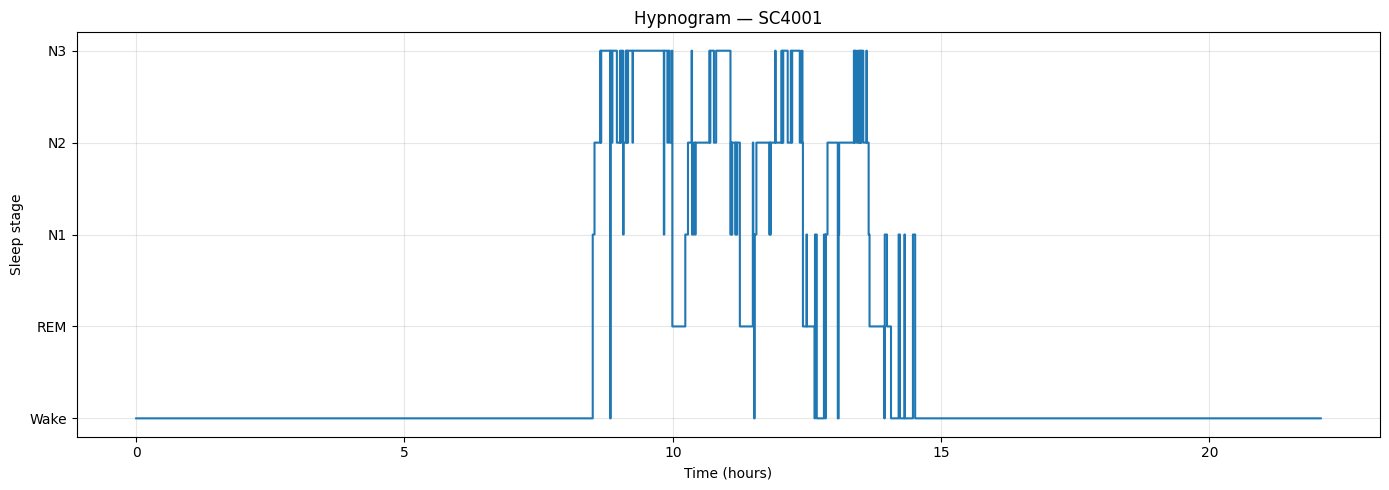

Saved: C:\Users\vi\Sleep staging + fragmentation detection\sleep-staging-fragmentation\figures\SC4001_hypnogram.png


In [20]:
plot_stage_map = {
    'W': 4,
    'REM': 3,
    'N1': 2,
    'N2': 1,
    'N3': 0
}

plot_labels = {
    4: 'Wake',
    3: 'REM',
    2: 'N1',
    1: 'N2',
    0: 'N3'
}

plot_df = epoch_df.copy()
plot_df['stage_num'] = plot_df['stage_label'].map(plot_stage_map)
plot_df['epoch_hour'] = plot_df['epoch_start_sec'] / 3600

plt.figure(figsize=(14, 5))
plt.step(plot_df['epoch_hour'], plot_df['stage_num'], where='post')

plt.yticks(list(plot_labels.keys()), [plot_labels[k] for k in plot_labels.keys()])
plt.gca().invert_yaxis()
plt.xlabel('Time (hours)')
plt.ylabel('Sleep stage')
plt.title(f"Hypnogram — {sample_pair['subject_prefix']}")
plt.grid(alpha=0.3)
plt.tight_layout()

out_path = FIGURES_DIR / f"{sample_pair['subject_prefix']}_hypnogram.png"
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

print('Saved:', out_path)

In [21]:
out_epoch_path = PROCESSED_DIR / f"{sample_pair['subject_prefix']}_epoch_index.csv"
epoch_df.to_csv(out_epoch_path, index=False)

print('Saved:', out_epoch_path)

Saved: C:\Users\vi\Sleep staging + fragmentation detection\sleep-staging-fragmentation\data\processed\SC4001_epoch_index.csv


In [22]:
all_epoch_rows = []

for pair in pairs:
    annotations = mne.read_annotations(pair['hypnogram_file'])

    annot_df = pd.DataFrame({
        'onset_sec': annotations.onset,
        'duration_sec': annotations.duration,
        'description': annotations.description
    })

    annot_df['stage_5class'] = annot_df['description'].map(stage_map)
    stage_df = annot_df[annot_df['stage_5class'].notna()].copy()

    for _, row in stage_df.iterrows():
        n_epochs = int(row['duration_sec'] // 30)

        for i in range(n_epochs):
            all_epoch_rows.append({
                'subject_id': pair['subject_prefix'],
                'epoch_start_sec': row['onset_sec'] + i * 30,
                'epoch_duration_sec': 30,
                'stage_label': row['stage_5class'],
                'original_description': row['description']
            })

all_epochs_df = pd.DataFrame(all_epoch_rows)

print(all_epochs_df.shape)
all_epochs_df.head()

(11129, 5)


,subject_id,epoch_start_sec,epoch_duration_sec,stage_label,original_description
0,SC4001,0.0,30,W,Sleep stage W
1,SC4001,30.0,30,W,Sleep stage W
2,SC4001,60.0,30,W,Sleep stage W
3,SC4001,90.0,30,W,Sleep stage W
4,SC4001,120.0,30,W,Sleep stage W


In [23]:
all_epochs_path = PROCESSED_DIR / 'sleep_edf_epoch_index.csv'
all_epochs_df.to_csv(all_epochs_path, index=False)

print('Saved:', all_epochs_path)

Saved: C:\Users\vi\Sleep staging + fragmentation detection\sleep-staging-fragmentation\data\processed\sleep_edf_epoch_index.csv


In [24]:
all_epochs_path = PROCESSED_DIR / 'sleep_edf_epoch_index.csv'
all_epochs_df.to_csv(all_epochs_path, index=False)

print('Saved:', all_epochs_path)

Saved: C:\Users\vi\Sleep staging + fragmentation detection\sleep-staging-fragmentation\data\processed\sleep_edf_epoch_index.csv


In [25]:
all_epochs_df.groupby('subject_id')['stage_label'].value_counts().unstack(fill_value=0)

stage_label,N1,N2,N3,REM,W
subject_id,,,,,
SC4001,58,250,220,125,1997
SC4002,59,373,297,215,1885
SC4011,109,562,105,170,1856
SC4012,92,660,96,176,1824


## Conclusion

In this notebook, raw Sleep-EDF PSG and hypnogram files were loaded and converted into a 30-second epoch-level table suitable for downstream sleep staging.

The main outputs are:
- subject/file pairing
- annotation-to-stage mapping
- epoch-level sleep stage labels
- sample hypnogram visualization

The next step is to extract epoch-level signal features from PSG channels and build a baseline sleep staging classifier.